# EZIE Mag - Daily Notebook

**Project:** EZIE Mag Summer Research Project

This notebook is **Stage 2** of the EZIE Mag pipeline: it loads one
day's already-cleaned data from `data/processed/` and produces
labeled time-series plots for review.

This notebook does **no** cleaning, gap-filling, or feature
engineering of its own - all of that happens once, upstream, in the
Processing Notebook. If the day you want to look at hasn't been
processed yet, run it through the Processing Notebook first.

**Plots produced:**
- Bx, By, Bz (raw components)
- B_total (total field magnitude)
- Bh (horizontal field magnitude) and D (declination)
- Central time view
- Comparison with USGS reference observatories (FRD, Boulder)

## 1. Setup

Import required libraries and the project's helper module.

In [30]:
# --- Path setup ---
# This notebook lives in notebooks/, but ezie_utils.py and the data/
# folder live one level up, at the project root.
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

import ezie_utils

## 2. Settings

Enter the date to load and select which device(s) to display.
If multiple devices are selected, their data will be plotted
together for direct comparison.

The date must already have been processed through the Processing
Notebook for each selected device - if a processed file doesn't
exist for a given date/device combination, it will be skipped
with a warning.

In [31]:
PROCESSED_DIR = "../data/processed"

# --- Date input ---
date_str = input("Enter date (YYYYMMDD): ").strip()

if not (date_str.isdigit() and len(date_str) == 8):
    raise ValueError(
        f"Invalid date '{date_str}'. Please enter exactly 8 digits "
        f"in YYYYMMDD format (e.g. 20260609)."
    )

import datetime
try:
    datetime.datetime.strptime(date_str, "%Y%m%d")
except ValueError:
    raise ValueError(
        f"'{date_str}' is not a valid calendar date."
    )

# --- Device selection ---
# Show all available fingerprints so the user knows what's available
available = ezie_utils.list_available_fingerprints(PROCESSED_DIR)

if not available:
    raise FileNotFoundError(
        f"No processed data found in {PROCESSED_DIR}. "
        f"Run the Processing Notebook first."
    )

print("\nAvailable devices:")
for fp, name in available:
    print(f"  {fp} ({name})")

# --- Single or multiple devices ---
mode = input(
    "\nLoad (s)ingle device or (m)ultiple devices? [s/m]: "
).strip().lower()

if mode not in ("s", "m"):
    raise ValueError(
        f"Invalid choice '{mode}'. Please enter 's' or 'm'."
    )

if mode == "s":
    fingerprint = input("Enter device fingerprint: ").strip()
    if not any(fp == fingerprint for fp, _ in available):
        raise ValueError(
            f"Fingerprint '{fingerprint}' not found in {PROCESSED_DIR}. "
            f"Check available devices above."
        )
    FINGERPRINTS = [fingerprint]

else:
    print("Enter fingerprints one at a time.")
    print("Press Enter with no input when done.")
    FINGERPRINTS = []
    while True:
        fp = input(f"  Fingerprint {len(FINGERPRINTS) + 1}: ").strip()
        if fp == "":
            if len(FINGERPRINTS) == 0:
                print("  Please enter at least one fingerprint.")
                continue
            break
        if not any(f == fp for f, _ in available):
            print(f"  Warning: '{fp}' not found in {PROCESSED_DIR} - skipping.")
            continue
        FINGERPRINTS.append(fp)

# --- Build processed file paths and load ---
# Attempt to load each fingerprint's file for this date.
# Missing files are skipped with a warning rather than raising
# an error, so a multi-device run still works even if one
# device doesn't have data for this particular day.
dfs = {}

for fp in FINGERPRINTS:
    path = os.path.join(
        PROCESSED_DIR, fp,
        f"eziemag_{date_str}_{fp}_processed.csv"
    )
    if not os.path.exists(path):
        print(f"Warning: no processed file found for {fp} on {date_str} - skipping.")
        continue

    df_loaded = pd.read_csv(path, index_col="timeString", parse_dates=True)
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    dfs[fp] = df_loaded
    print(f"Loaded: {fp} ({name}) - {df_loaded.shape[0]} rows")

if not dfs:
    raise FileNotFoundError(
        f"No processed files found for date {date_str} "
        f"for any of the selected devices."
    )

# --- For single device, keep df as a convenience variable ---
# Single device mode: df points to the one loaded DataFrame so
# all existing single-device plotting cells work unchanged.
# Multi-device mode: use dfs dict directly in plotting cells.
if len(dfs) == 1:
    df = list(dfs.values())[0]
    fingerprint = list(dfs.keys())[0]
    print(f"\nSingle device mode - df is ready.")
else:
    print(f"\nMultiple device mode - {len(dfs)} device(s) loaded into dfs dict.")
    print("Use dfs[fingerprint] to access each device's DataFrame.")

Enter date (YYYYMMDD):  20260626



Available devices:
  .ipynb_checkpoints (Unknown device)
  AAAAAIzs1uUA (Zane (Keller, TX))



Load (s)ingle device or (m)ultiple devices? [s/m]:  s
Enter device fingerprint:  AAAAAIzs1uUA


Loaded: AAAAAIzs1uUA (Zane (Keller, TX)) - 1440 rows

Single device mode - df is ready.


## 3. Load Data

Data was already loaded in the Settings section above. This cell
provides a quick sanity check - confirming the shape, time range,
and device details for each loaded DataFrame before plotting.

In [32]:
for fp, df_device in dfs.items():
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")

    print(f"\n{'='*60}")
    print(f"Device: {fp} ({name})")
    print(f"{'='*60}")
    print(f"Shape:      {df_device.shape}")
    print(f"Time range: {df_device.index.min()} to {df_device.index.max()}")
    print(f"Missing:    {df_device['flag_missing'].sum()} minute(s)")

    # Quick flag summary so you know going in whether this day
    # had any quality issues before looking at the plots
    flag_cols = [c for c in df_device.columns if c.startswith("flag_")]
    flagged = {c: int(df_device[c].sum()) for c in flag_cols if df_device[c].sum() > 0}

    if flagged:
        print("Flags raised:")
        for flag, count in flagged.items():
            print(f"  {flag}: {count} row(s)")
    else:
        print("Flags raised: none")

    display(df_device.head())


Device: AAAAAIzs1uUA (Zane (Keller, TX))
Shape:      (1440, 37)
Time range: 2026-06-26 00:00:00+00:00 to 2026-06-26 23:59:00+00:00
Missing:    1 minute(s)
Flags raised:
  flag_outlier_bx: 6 row(s)
  flag_outlier_bh: 1 row(s)
  flag_low_nsamp: 15 row(s)
  flag_sensor_disturbed: 27 row(s)
  flag_missing: 1 row(s)


,tval,intt,nsamp,stid,fingerprint,lat,lon,alt,tres,ctemp,...,flag_outlier_by,flag_outlier_bz,flag_outlier_bh,flag_outlier_ctemp,flag_outlier_imu_ctemp,flag_low_nsamp,flag_gps,flag_sensor_disturbed,flag_config_change,flag_missing
timeString,,,,,,,,,,,,,,,,,,,,,
2026-06-26 00:00:00+00:00,1.782432e+09,60.0,2004.0,"""eziemag""",AAAAAIzs1uUA,32.951998,-97.255777,227.4,3.0,23.625,...,False,False,False,False,False,False,False,False,False,False
2026-06-26 00:01:00+00:00,1.782432e+09,60.0,2029.0,"""eziemag""",AAAAAIzs1uUA,32.951998,-97.255777,227.4,3.0,23.625,...,False,False,False,False,False,False,False,False,False,False
2026-06-26 00:02:00+00:00,1.782432e+09,60.0,2033.0,"""eziemag""",AAAAAIzs1uUA,32.951998,-97.255777,227.4,3.0,23.625,...,False,False,False,False,False,False,False,False,False,False
2026-06-26 00:03:00+00:00,1.782432e+09,60.0,2023.0,"""eziemag""",AAAAAIzs1uUA,32.951998,-97.255777,227.4,3.0,23.625,...,False,False,False,False,False,False,False,False,False,False
2026-06-26 00:04:00+00:00,1.782432e+09,60.0,2011.0,"""eziemag""",AAAAAIzs1uUA,32.951998,-97.255777,227.4,3.0,23.625,...,False,False,False,False,False,False,False,False,False,False


## 4. Daily Plots: Bx, By, Bz

Time-series plots of the three raw magnetic field components, in
sensor units (nT, uncalibrated). The x-axis uses real UTC timestamps,
so any data gaps appear naturally as breaks in the line rather than
misleading straight-line connections.

In multi-device mode, each device is plotted on the same axes for
direct comparison.

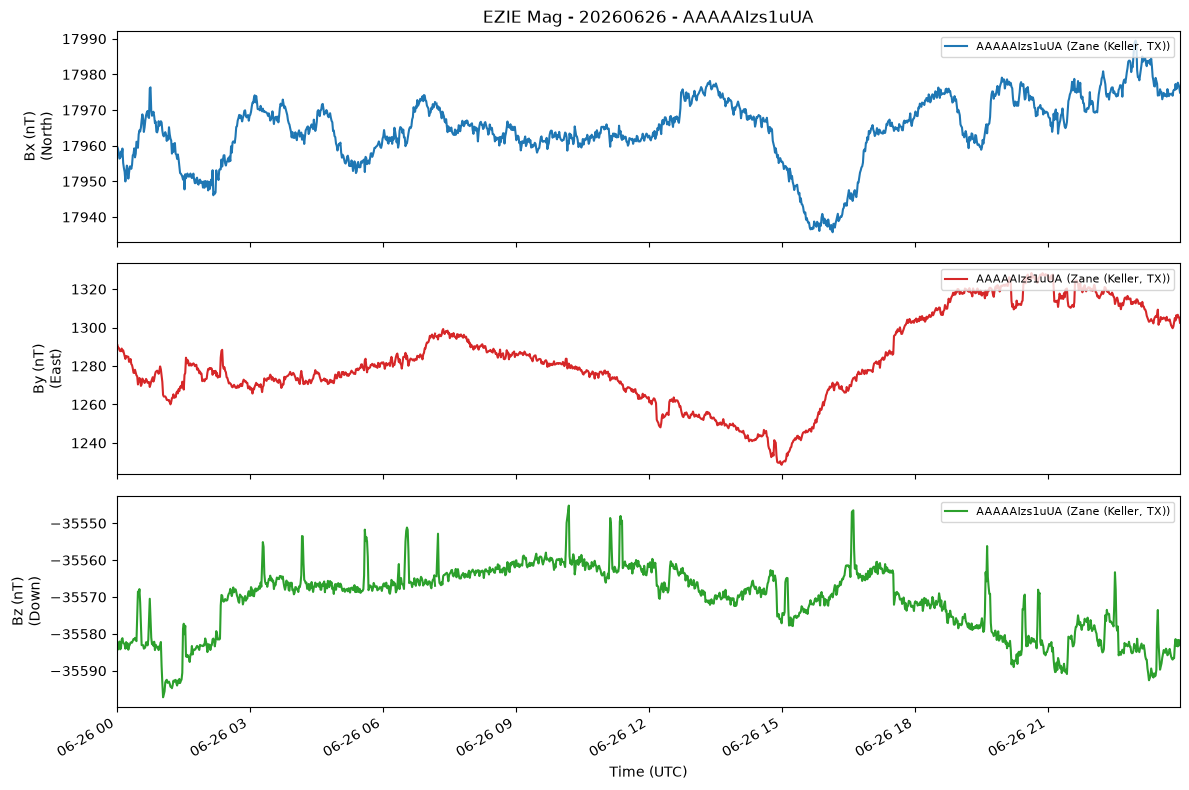

In [33]:
# Line styles cycle across devices so they're distinguishable
# in multi-device mode while component colors stay consistent.
line_styles = ["-", "--", ":", "-."]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    axes[0].plot(df_device.index, df_device["Bx"],
                 color="tab:blue", linestyle=ls, label=label)
    axes[1].plot(df_device.index, df_device["By"],
                 color="tab:red", linestyle=ls, label=label)
    axes[2].plot(df_device.index, df_device["Bz"],
                 color="tab:green", linestyle=ls, label=label)

axes[0].set_ylabel("Bx (nT)\n(North)")
axes[1].set_ylabel("By (nT)\n(East)")
axes[2].set_ylabel("Bz (nT)\n(Down)")
axes[2].set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
axes[0].set_title(f"EZIE Mag - {date_str} - {fp_str}")

first_df = list(dfs.values())[0]
for ax in axes:
    ax.set_xlim(first_df.index.min(), first_df.index.max())
    ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Total Field Magnitude (B_total)

$$B_{total} = \sqrt{B_x^2 + B_y^2 + B_z^2}$$

Rotation-independent overall field strength, comparable to an
observatory's reported F value. In multi-device mode, each device
is plotted on the same axes for direct comparison.

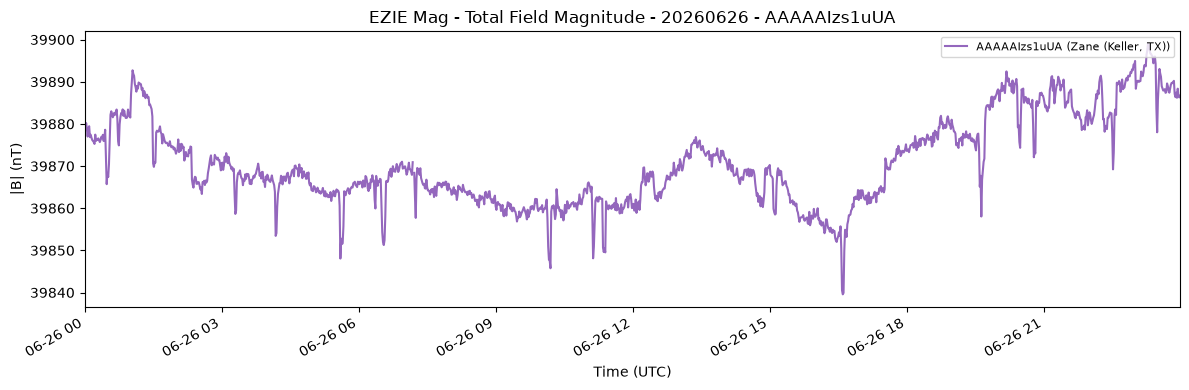

In [34]:
line_styles = ["-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(12, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    ax.plot(df_device.index, df_device["B_total"],
            color="tab:purple", linestyle=ls, label=label)

ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
ax.set_title(f"EZIE Mag - Total Field Magnitude - {date_str} - {fp_str}")

first_df = list(dfs.values())[0]
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Horizontal Field Magnitude (Bh)

$$B_h = \sqrt{B_x^2 + B_y^2}$$

Combines the North and East components only, excluding the vertical
Down component. This is the primary scientific comparison metric
since Bz can differ significantly between stations due to local
conditions. In multi-device mode, each device is plotted on the
same axes for direct comparison.

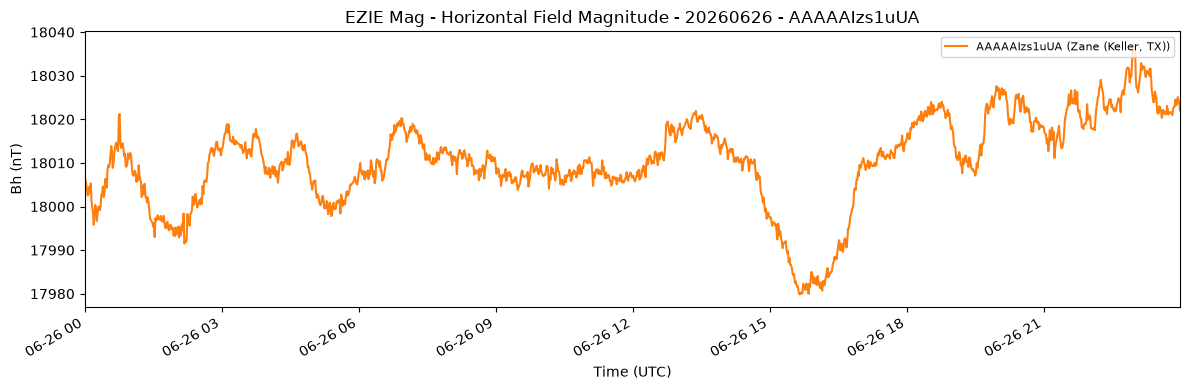

In [35]:
line_styles = ["-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(12, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    ax.plot(df_device.index, df_device["Bh"],
            color="tab:orange", linestyle=ls, label=label)

ax.set_ylabel("Bh (nT)")
ax.set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
ax.set_title(
    f"EZIE Mag - Horizontal Field Magnitude - {date_str} - {fp_str}"
)

first_df = list(dfs.values())[0]
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Declination (D)

$$D = \arctan2(B_y, B_x)$$

The angle, in degrees, of the horizontal field relative to the
sensor's +X axis. Computed using `atan2` rather than plain
`arctan(By/Bx)` since `atan2` correctly handles all four quadrants.
Still relative to the sensor's own axis until affine calibration
is applied - not yet true magnetic North. In multi-device mode,
each device is plotted on the same axes for direct comparison.

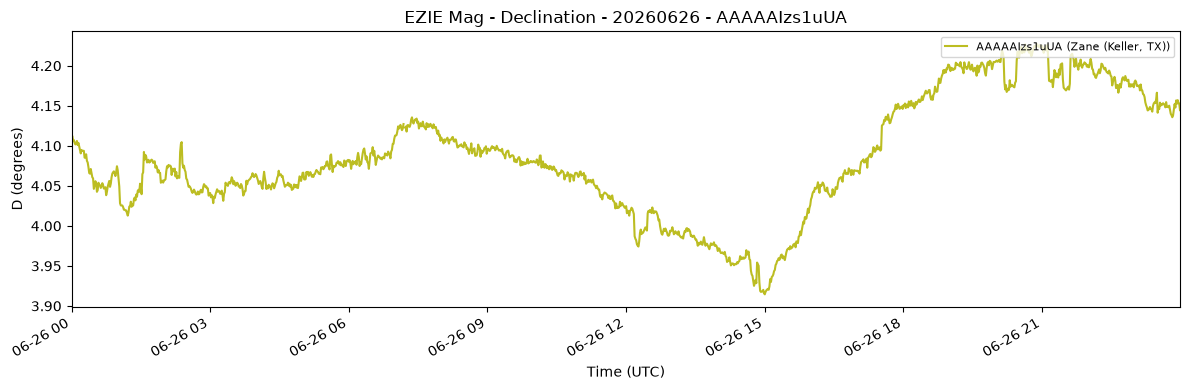

In [36]:
line_styles = ["-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(12, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    label = f"{fp} ({name})"
    ls = line_styles[i % len(line_styles)]

    ax.plot(df_device.index, df_device["D"],
            color="tab:olive", linestyle=ls, label=label)

ax.set_ylabel("D (degrees)")
ax.set_xlabel("Time (UTC)")

fp_str = " | ".join(FINGERPRINTS)
ax.set_title(f"EZIE Mag - Declination - {date_str} - {fp_str}")

first_df = list(dfs.values())[0]
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Comparison with USGS Observatories

Overlays EZIE data with public reference data from four USGS
geomagnetic observatories:

| Code | Location | Distance from Arlington, TX |
|---|---|---|
| BSL | Stennis Space Center, MS | ~500 miles east (closest) |
| TUC | Tucson, AZ | ~900 miles west |
| BOU | Boulder, CO | ~900 miles north |
| FRD | Fredericksburg, VA | ~1,400 miles northeast |

Each dataset is **min-max normalized** before plotting:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

This scales every dataset to a 0-1 range where 0 = that dataset's
minimum and 1 = that dataset's maximum for the day, putting all
sources on a common scale regardless of absolute units or amplitude
differences. This makes shape/trend comparison directly readable —
if EZIE and the observatories respond to the same geomagnetic event,
their normalized lines will move together.

**Note on outliers:** a single spike (e.g. train interference) can
compress the rest of the day's variation into a narrow band near 0
since it becomes the max. If this is observed, consider re-running
with flagged outlier rows excluded from the normalization bounds.

**Known observation:** the East (By vs Y) component appears inverted
relative to the observatories due to the RM3100 sensor's internal
+Y axis pointing West rather than East. This will be corrected by
affine calibration.

Requires the `requests` library.

Fetching BSL...
  BSL: 1441 rows loaded
Fetching TUC...
  TUC: 1441 rows loaded
Fetching BOU...
  BOU: 1441 rows loaded
Fetching FRD...
  FRD: 1441 rows loaded


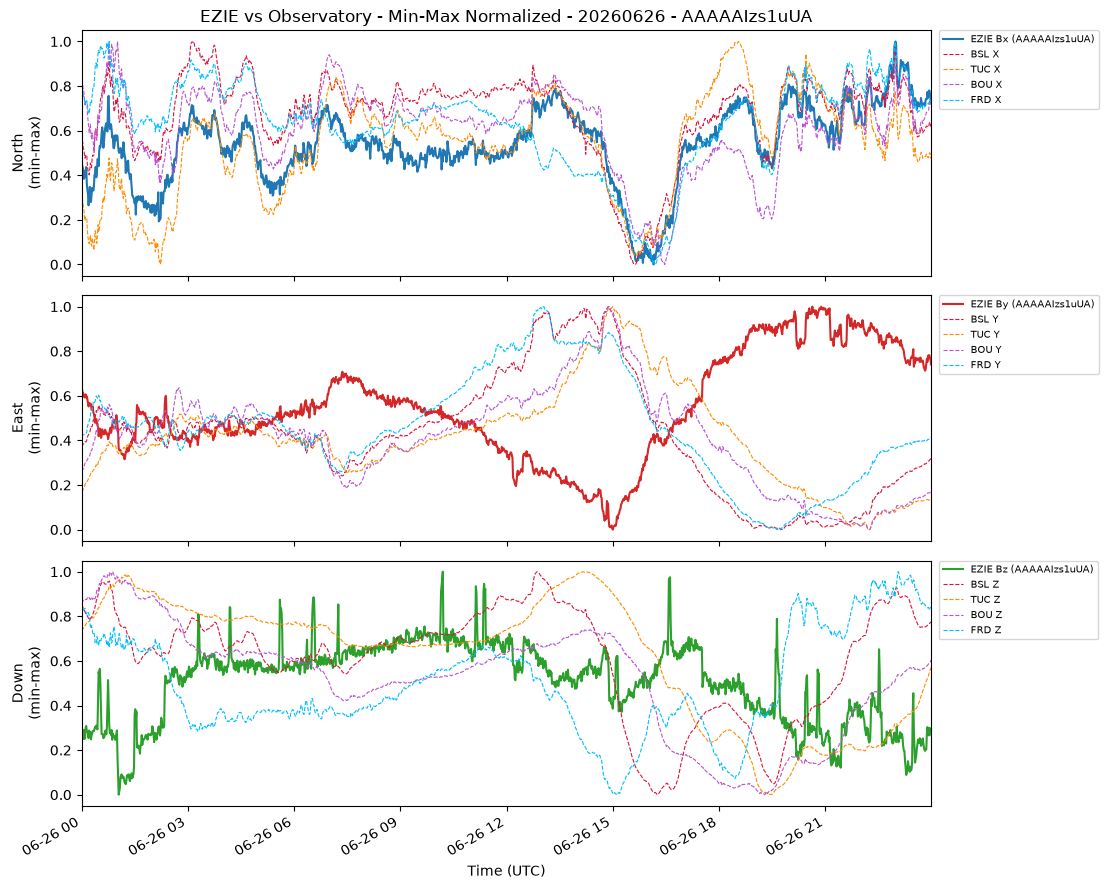

In [37]:
import requests

# --- Fetch reference data from all four observatories ---
first_df = list(dfs.values())[0]
day_start = first_df.index.min()
if day_start.tz is None:
    day_start = pd.Timestamp(day_start).tz_localize("UTC")

day_end = day_start.floor("D") + pd.Timedelta(days=1)

# Four observatories ordered by proximity to Arlington, TX.
observatories = {
    "BSL": "crimson",       # Stennis, MS  - closest (~500 mi east)
    "TUC": "darkorange",    # Tucson, AZ   - (~900 mi west)
    "BOU": "mediumorchid",  # Boulder, CO  - (~900 mi north)
    "FRD": "deepskyblue",   # Fredericksburg, VA - (~1400 mi northeast)
}

obs_dfs = {}

for obs_id in observatories:
    url = (
        "https://geomag.usgs.gov/ws/data/"
        f"?id={obs_id}"
        f"&starttime={day_start.floor('D').strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&elements=X,Y,Z,F"
        f"&sampling_period=60"
        f"&format=json"
    )

    print(f"Fetching {obs_id}...")

    try:
        for attempt in range(3):
            try:
                response = requests.get(url, timeout=60)
                response.raise_for_status()
                data = response.json()
                break
            except Exception:
                if attempt < 2:
                    print(f"  {obs_id}: retrying ({attempt + 1}/3)...")
                else:
                    raise

        times = pd.to_datetime(data["times"])
        obs_df = pd.DataFrame(index=times)
        for element in data["values"]:
            name = element["metadata"]["element"]
            obs_df[name] = element["values"]

        obs_dfs[obs_id] = obs_df
        print(f"  {obs_id}: {obs_df.shape[0]} rows loaded")

    except Exception as e:
        print(f"  {obs_id}: failed after 3 attempts ({e})")

# --- Helper function for min-max normalization ---
# Scales a series to 0-1 range based on its own min and max.
# NaN values are ignored in the min/max calculation and remain
# NaN after normalization so gaps still show as breaks in plots.
def minmax_norm(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        # Avoid division by zero if the series is constant
        return series * 0
    return (series - s_min) / (s_max - s_min)

# --- Overlay plots: min-max normalized on a shared 0-1 axis ---
components = [
    ("Bx", "X", "North", "tab:blue"),
    ("By", "Y", "East",  "tab:red"),
    ("Bz", "Z", "Down",  "tab:green")
]

line_styles = ["-", "--", ":", "-."]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, (ezie_col, obs_col, label, ezie_color) in zip(axes, components):

    # Plot each EZIE device using the component's standard color
    for i, (fp, df_device) in enumerate(dfs.items()):
        name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
        ls = line_styles[i % len(line_styles)]
        ezie_norm = minmax_norm(df_device[ezie_col])
        ax.plot(df_device.index, ezie_norm,
                color=ezie_color, linestyle=ls, linewidth=1.5,
                label=f"EZIE {ezie_col} ({fp})")

    # Plot each observatory with a thinner dashed line so EZIE
    # stays visually prominent
    for obs_id, color in observatories.items():
        if obs_id in obs_dfs and obs_col in obs_dfs[obs_id].columns:
            obs_norm = minmax_norm(obs_dfs[obs_id][obs_col])
            ax.plot(obs_dfs[obs_id].index, obs_norm,
                    color=color, linestyle="--", linewidth=0.8,
                    label=f"{obs_id} {obs_col}")

    ax.set_ylabel(f"{label}\n(min-max)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(first_df.index.min(), first_df.index.max())
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
              fontsize=7, borderaxespad=0)

fp_str = " | ".join(FINGERPRINTS)
axes[0].set_title(
    f"EZIE vs Observatory - Min-Max Normalized - {date_str} - {fp_str}"
)
axes[-1].set_xlabel("Time (UTC)")
fig.autofmt_xdate()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

## 9. Total Field and Horizontal Field - Observatory Comparison

Z-score normalized comparison of EZIE's derived fields against the
corresponding observatory quantities:

- **B_total** vs observatory **F** (total field magnitude)
- **Bh** vs observatory **H** (horizontal field magnitude)

Same min-max normalization as Section 8 - each dataset is
independently scaled to 0-1 so shape/trend can be compared directly
regardless of absolute scale differences. Bh is the primary
scientific comparison metric since Bz varies significantly between
stations due to local conditions.

Requires the `requests` library.

Fetching H, F for BSL...
  BSL: 1441 rows loaded
Fetching H, F for TUC...
  TUC: 1441 rows loaded
Fetching H, F for BOU...
  BOU: 1441 rows loaded
Fetching H, F for FRD...
  FRD: 1441 rows loaded


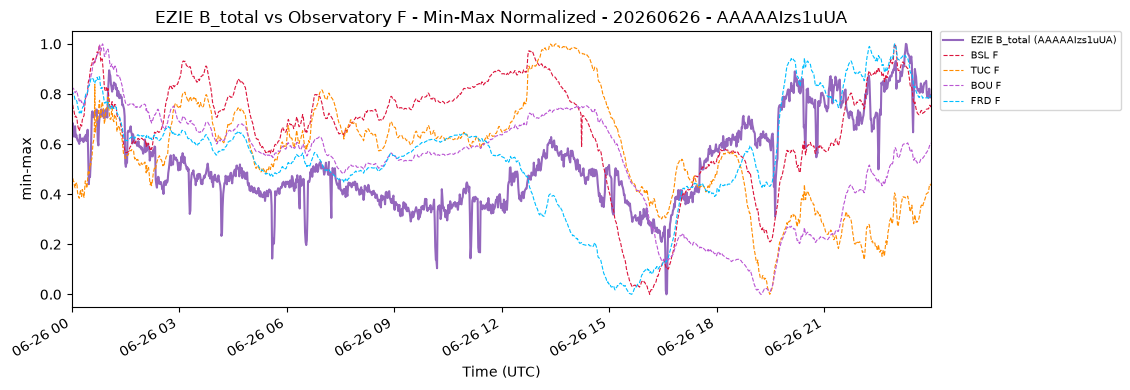

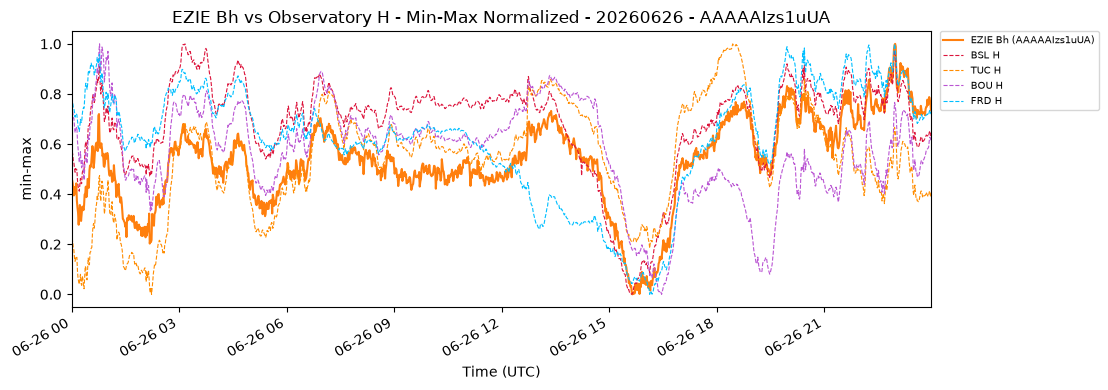

In [38]:
# --- Fetch H and F from all four observatories ---
# Section 8 fetched X, Y, Z, F — we need H as well for the Bh
# comparison. Re-fetch with H and F only to keep the request small.
obs_dfs_hf = {}

for obs_id in observatories:
    url = (
        "https://geomag.usgs.gov/ws/data/"
        f"?id={obs_id}"
        f"&starttime={day_start.floor('D').strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&elements=H,F"
        f"&sampling_period=60"
        f"&format=json"
    )

    print(f"Fetching H, F for {obs_id}...")

    try:
        for attempt in range(3):
            try:
                response = requests.get(url, timeout=60)
                response.raise_for_status()
                data = response.json()
                break
            except Exception:
                if attempt < 2:
                    print(f"  {obs_id}: retrying ({attempt + 1}/3)...")
                else:
                    raise

        times = pd.to_datetime(data["times"])
        obs_df = pd.DataFrame(index=times)
        for element in data["values"]:
            name = element["metadata"]["element"]
            obs_df[name] = element["values"]

        obs_dfs_hf[obs_id] = obs_df
        print(f"  {obs_id}: {obs_df.shape[0]} rows loaded")

    except Exception as e:
        print(f"  {obs_id}: failed after 3 attempts ({e})")

# --- B_total vs observatory F ---
fig, ax = plt.subplots(figsize=(12, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    ls = line_styles[i % len(line_styles)]
    ezie_norm = minmax_norm(df_device["B_total"])
    ax.plot(df_device.index, ezie_norm,
            color="tab:purple", linestyle=ls, linewidth=1.5,
            label=f"EZIE B_total ({fp})")

for obs_id, color in observatories.items():
    if obs_id in obs_dfs_hf and "F" in obs_dfs_hf[obs_id].columns:
        obs_norm = minmax_norm(obs_dfs_hf[obs_id]["F"])
        ax.plot(obs_dfs_hf[obs_id].index, obs_norm,
                color=color, linestyle="--", linewidth=0.8,
                label=f"{obs_id} F")

ax.set_ylabel("min-max")
ax.set_xlabel("Time (UTC)")
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.set_title(
    f"EZIE B_total vs Observatory F - "
    f"Min-Max Normalized - {date_str} - {fp_str}"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=7, borderaxespad=0)
fig.autofmt_xdate()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

# --- Bh vs observatory H ---
fig, ax = plt.subplots(figsize=(12, 4))

for i, (fp, df_device) in enumerate(dfs.items()):
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")
    ls = line_styles[i % len(line_styles)]
    ezie_norm = minmax_norm(df_device["Bh"])
    ax.plot(df_device.index, ezie_norm,
            color="tab:orange", linestyle=ls, linewidth=1.5,
            label=f"EZIE Bh ({fp})")

for obs_id, color in observatories.items():
    if obs_id in obs_dfs_hf and "H" in obs_dfs_hf[obs_id].columns:
        obs_norm = minmax_norm(obs_dfs_hf[obs_id]["H"])
        ax.plot(obs_dfs_hf[obs_id].index, obs_norm,
                color=color, linestyle="--", linewidth=0.8,
                label=f"{obs_id} H")

ax.set_ylabel("min-max")
ax.set_xlabel("Time (UTC)")
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(first_df.index.min(), first_df.index.max())
ax.set_title(
    f"EZIE Bh vs Observatory H - "
    f"Min-Max Normalized - {date_str} - {fp_str}"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1),
          fontsize=7, borderaxespad=0)
fig.autofmt_xdate()
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

## 10. Summary Statistics

Quick overview of the day's magnetic field data across all loaded
devices - useful for weekly reports and spotting anomalies at a
glance. Flag column counts are included so any quality issues
identified during processing are immediately visible alongside
the measurements.

In [39]:
for fp, df_device in dfs.items():
    name = ezie_utils.STATION_NAMES.get(fp, "Unknown device")

    print(f"\n{'='*60}")
    print(f"Summary Statistics: {date_str}")
    print(f"Device: {fp} ({name})")
    print(f"{'='*60}")

    # --- Measurement statistics ---
    display(df_device[["Bx", "By", "Bz", "B_total", "Bh", "D"]].describe())

    # --- Flag summary ---
    print("\nFlag Summary:")
    flag_cols = [c for c in df_device.columns if c.startswith("flag_")]
    flagged = {
        c: int(df_device[c].sum())
        for c in flag_cols
        if df_device[c].sum() > 0
    }

    if flagged:
        for flag, count in flagged.items():
            print(f"  {flag}: {count} row(s)")
    else:
        print("  No flags raised for this day.")


Summary Statistics: 20260626
Device: AAAAAIzs1uUA (Zane (Keller, TX))


,Bx,By,Bz,B_total,Bh,D
count,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000
mean,17964.648208,1283.021677,-35570.994639,39870.678288,18010.420503,4.085063
std,9.352366,23.089739,9.199106,10.352827,10.167872,0.072344
min,17935.720694,1228.637725,-35597.189462,39839.570662,17979.857539,3.914488
25%,17960.913903,1269.953444,-35577.955620,39863.085059,18006.258357,4.044925
50%,17965.174099,1279.860545,-35568.534128,39868.292108,18010.730967,4.075943
75%,17971.013265,1302.556972,-35563.963208,39877.091265,18017.265922,4.145543
max,17989.484197,1328.322109,-35545.210171,39898.994781,18037.305175,4.227316



Flag Summary:
  flag_outlier_bx: 6 row(s)
  flag_outlier_bh: 1 row(s)
  flag_low_nsamp: 15 row(s)
  flag_sensor_disturbed: 27 row(s)
  flag_missing: 1 row(s)
